# Workshop 02 - Object detection using web camera

## Name: VENKATA MOHAN N
## Register number : 212224230298

In [11]:
import cv2

for i in range(5):

    print("\nTesting camera", i)

    cap = cv2.VideoCapture(i, cv2.CAP_DSHOW)

    print("Opened:", cap.isOpened())

    ret, frame = cap.read()

    print("Read:", ret)

    cap.release()


Testing camera 0
Opened: True
Read: True

Testing camera 1
Opened: False
Read: False

Testing camera 2
Opened: False
Read: False

Testing camera 3
Opened: False
Read: False

Testing camera 4
Opened: False
Read: False


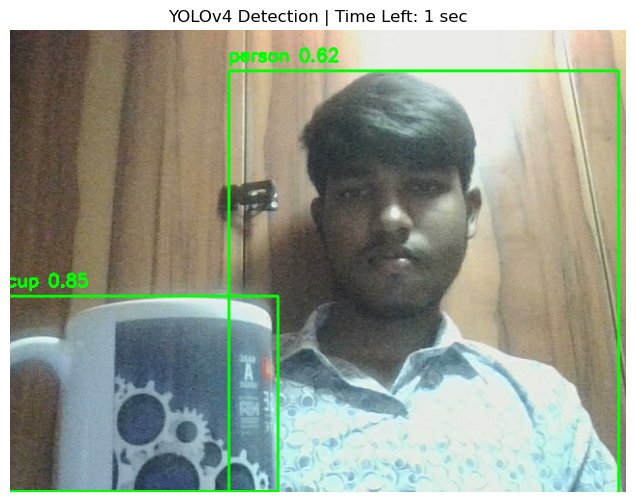

20 seconds completed. Stopping capture.
Capture finished.


In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

# Load YOLOv4 model
net = cv2.dnn.readNetFromDarknet(
    "yolov4.cfg",
    "yolov4.weights"
)

# Load COCO labels
with open("coco.names","r") as f:
    classes = [line.strip() for line in f.readlines()]

# Output layers
layer_names = net.getLayerNames()
output_layers = [
    layer_names[i-1]
    for i in net.getUnconnectedOutLayers().flatten()
]

# Webcam setup
cap = cv2.VideoCapture(0, cv2.CAP_DSHOW)

print("Opened:", cap.isOpened())

# Start timer
start_time = time.time()

while True:

    # Stop after 20 seconds
    elapsed = time.time() - start_time

    if elapsed >= 20:
        print("20 seconds completed. Stopping capture.")
        break

    ret, frame = cap.read()

    if not ret:
        print("Camera frame read failed.")
        break

    # Mirror webcam
    frame = cv2.flip(frame,1)

    height, width, _ = frame.shape

    # Create blob
    blob = cv2.dnn.blobFromImage(
        frame,
        1/255.0,
        (416,416),
        swapRB=True,
        crop=False
    )

    net.setInput(blob)

    outputs = net.forward(output_layers)

    boxes = []
    confidences = []
    class_ids = []

    # Detection
    for output in outputs:
        for detection in output:

            scores = detection[5:]
            class_id = np.argmax(scores)
            confidence = scores[class_id]

            if confidence > 0.5:

                center_x = int(detection[0]*width)
                center_y = int(detection[1]*height)

                w = int(detection[2]*width)
                h = int(detection[3]*height)

                x = int(center_x-w/2)
                y = int(center_y-h/2)

                boxes.append([x,y,w,h])
                confidences.append(float(confidence))
                class_ids.append(class_id)

    # Non-Max Suppression
    indexes = cv2.dnn.NMSBoxes(
        boxes,
        confidences,
        0.5,
        0.4
    )

    # Draw boxes
    if len(indexes) > 0:

        for i in indexes.flatten():

            x,y,w,h = boxes[i]

            label = classes[class_ids[i]]
            conf = confidences[i]

            cv2.rectangle(
                frame,
                (x,y),
                (x+w,y+h),
                (0,255,0),
                2
            )

            cv2.putText(
                frame,
                f"{label} {conf:.2f}",
                (x,y-10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0,255,0),
                2
            )

    # Convert BGR → RGB
    frame_rgb = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2RGB
    )

    clear_output(wait=True)

    plt.figure(figsize=(10,6))
    plt.imshow(frame_rgb)
    plt.axis("off")
    plt.title(f"YOLOv4 Detection | Time Left: {20-int(elapsed)} sec")
    plt.show()

# Release camera
cap.release()

print("Capture finished.")